In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('loan_data.csv')

In [405]:
df = pd.read_csv('loan_data.csv')

In [406]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [407]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


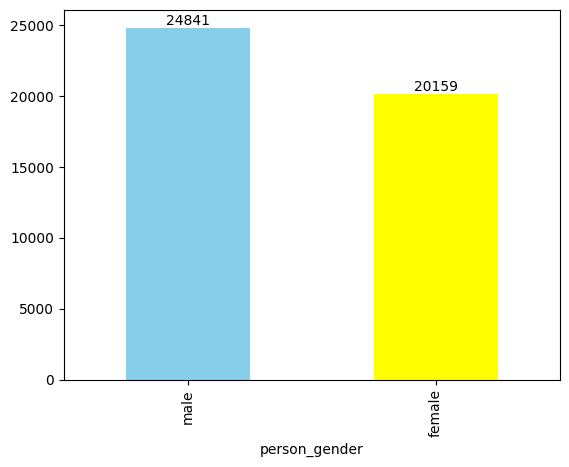

In [408]:
ax = df['person_gender'].value_counts().plot(kind='bar', color=['skyblue', 'yellow'])

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()


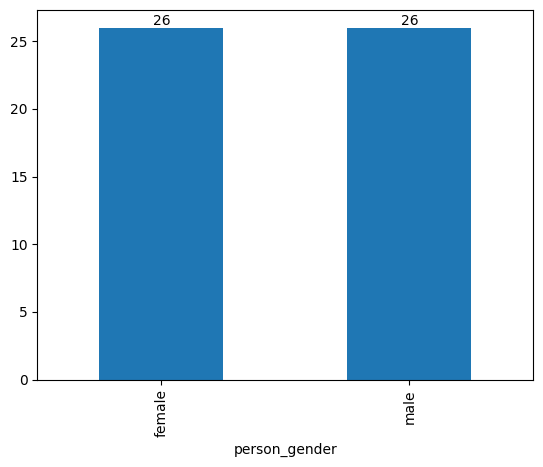

In [409]:
#find the average age gender wise 
ax = df.groupby('person_gender')['person_age'].median().plot(kind ='bar')

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

In [410]:
#find the gender who has master in eductaion 

df.groupby('person_gender').agg(gender_master = ('person_education', 'count'))

,gender_master
person_gender,
female,20159
male,24841


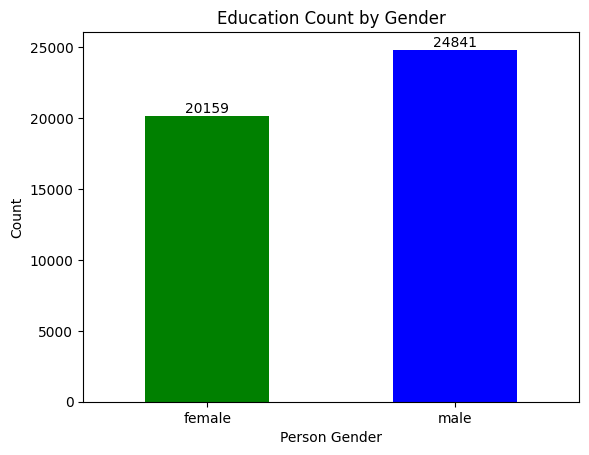

In [411]:
ax = df.groupby('person_gender')['person_education'].count().plot(kind='bar', color =['green','blue'])

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.xlabel('Person Gender')
plt.ylabel('Count')
plt.title('Education Count by Gender')
plt.xticks(rotation=0)
plt.show()

In [412]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


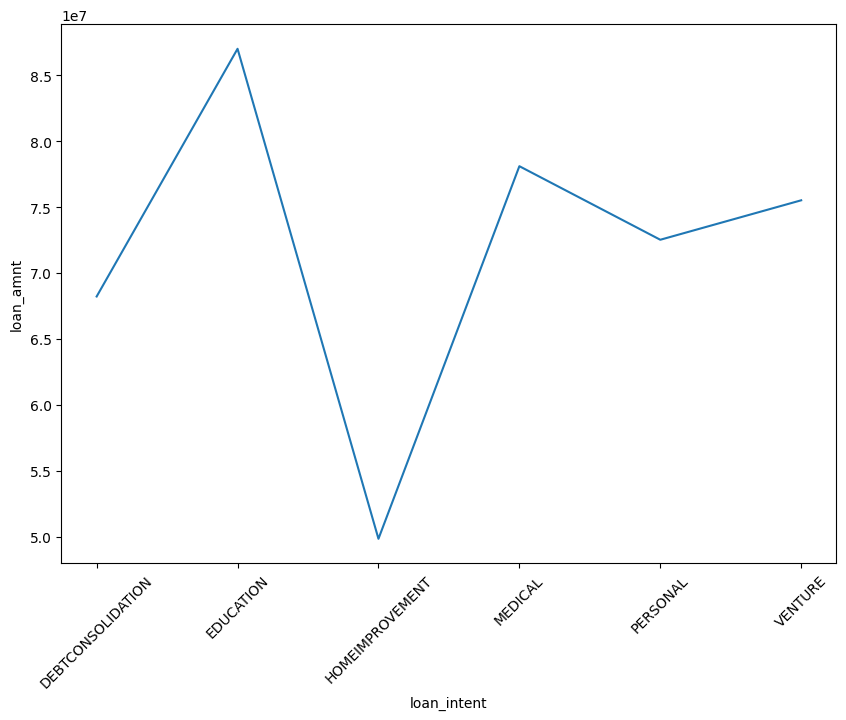

In [413]:
plt.figure(figsize=(10,7))
df.groupby('loan_intent')['loan_amnt'].sum().plot(kind = 'line')
plt.xticks(rotation=45)
plt.xlabel('loan_intent')
plt.ylabel('loan_amnt')
plt.show()

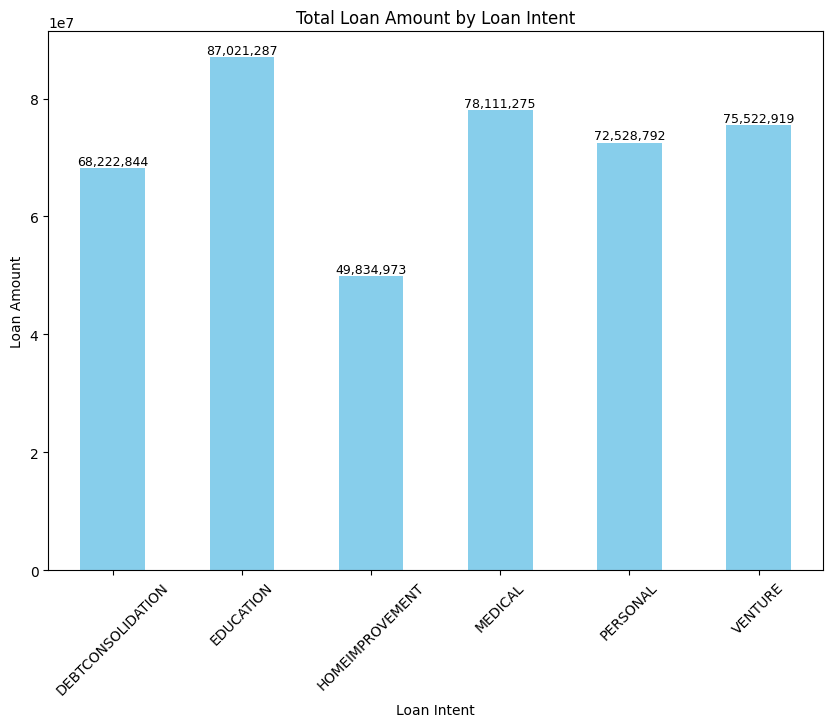

In [414]:
df_plot = df.groupby('loan_intent')['loan_amnt'].sum()

ax = df_plot.plot(kind='bar', figsize=(10, 7), color='skyblue')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=45)
plt.xlabel('Loan Intent')
plt.ylabel('Loan Amount')
plt.title('Total Loan Amount by Loan Intent')
plt.show()

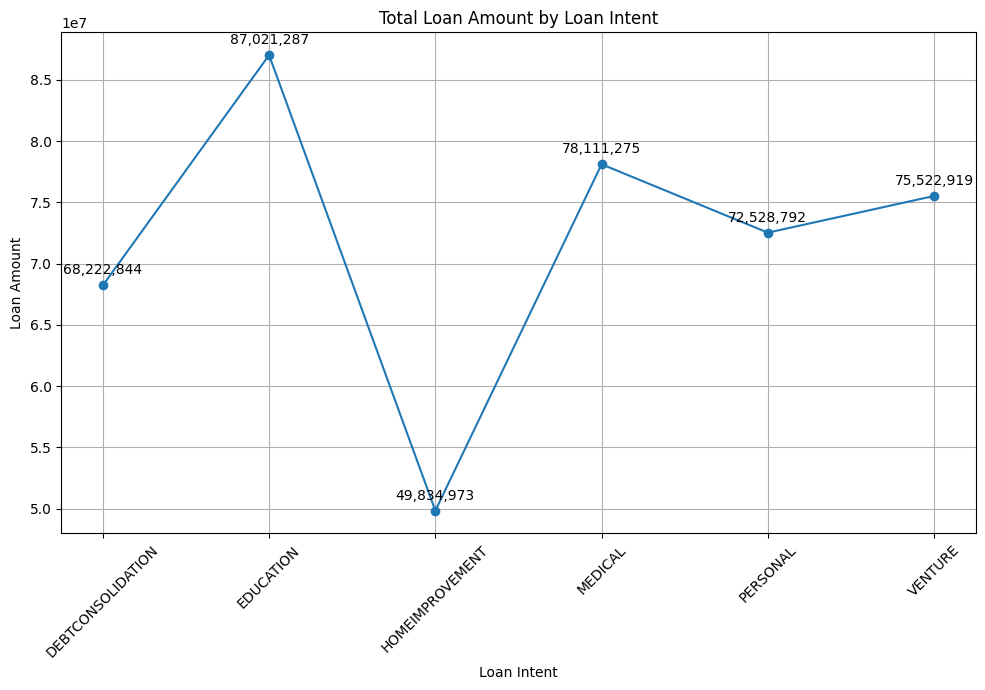

In [415]:
df_plot = df.groupby('loan_intent')['loan_amnt'].sum()

ax = df_plot.plot(kind='line', marker='o', figsize=(10, 7))
plt.grid()
for i, y in enumerate(df_plot.values):
    ax.annotate(
        f'{y:,.0f}',
        (i, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

plt.xticks(range(len(df_plot.index)), df_plot.index, rotation=45)
plt.xlabel('Loan Intent')
plt.ylabel('Loan Amount')
plt.title('Total Loan Amount by Loan Intent')
plt.tight_layout()
plt.show()

In [416]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


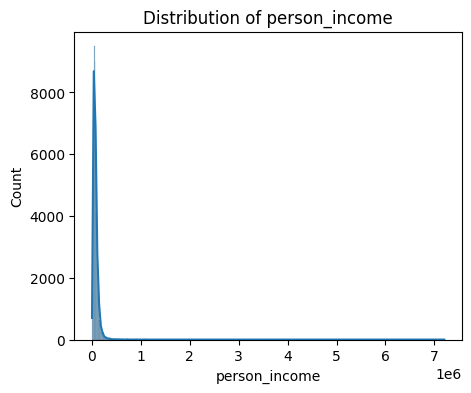

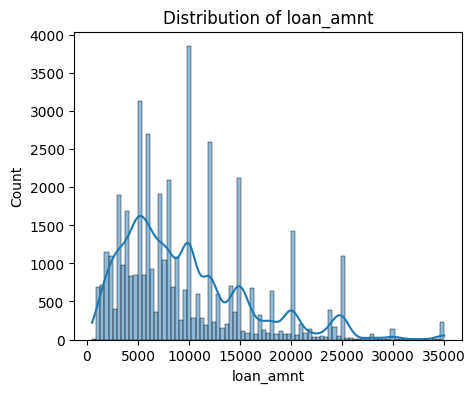

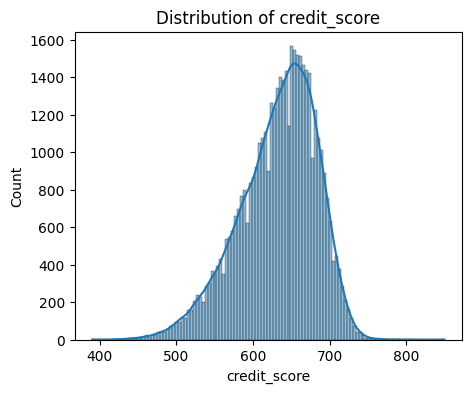

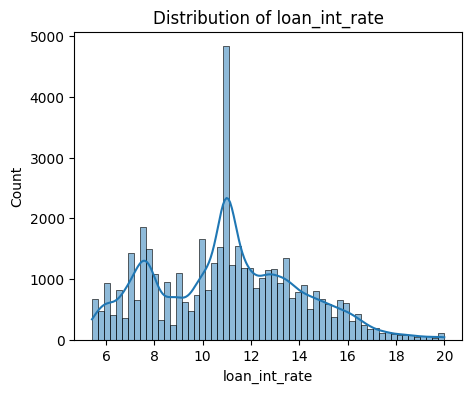

In [417]:
#hist plot for below numerical columns 
num_cols = ['person_income', 'loan_amnt', 'credit_score', 'loan_int_rate']

for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


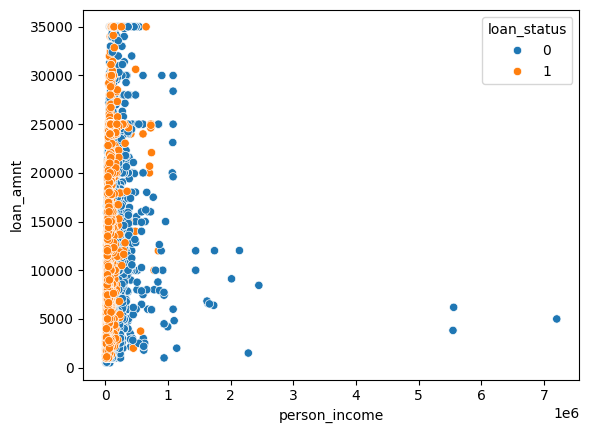

In [418]:
#scatter plot of person income Vs loam amount 
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=df)
plt.show()


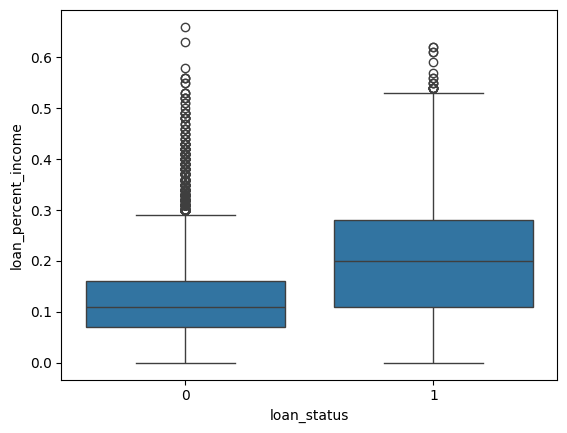

In [419]:
#box plot on Loan status and percent income
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.show()


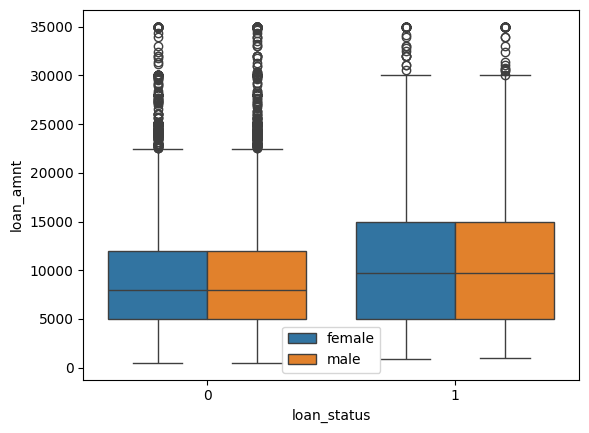

In [420]:
plt.figsize =(10,10)
sns.boxplot(x= 'loan_status', y = 'loan_amnt', data = df, hue ='person_gender')
plt.legend()
plt.show()

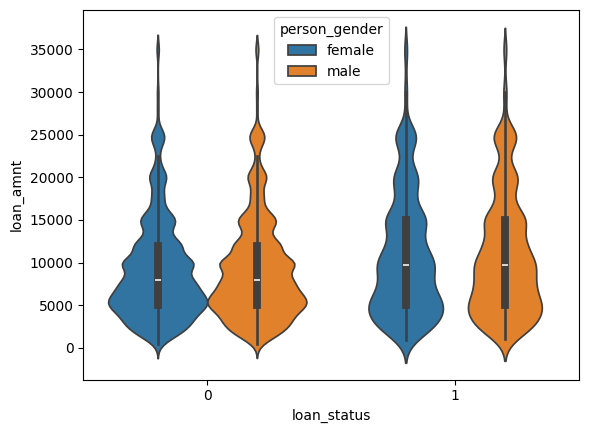

In [421]:
plt.figsize =(10,10)
sns.violinplot(x= 'loan_status', y = 'loan_amnt', data = df, hue ='person_gender')
plt.show()


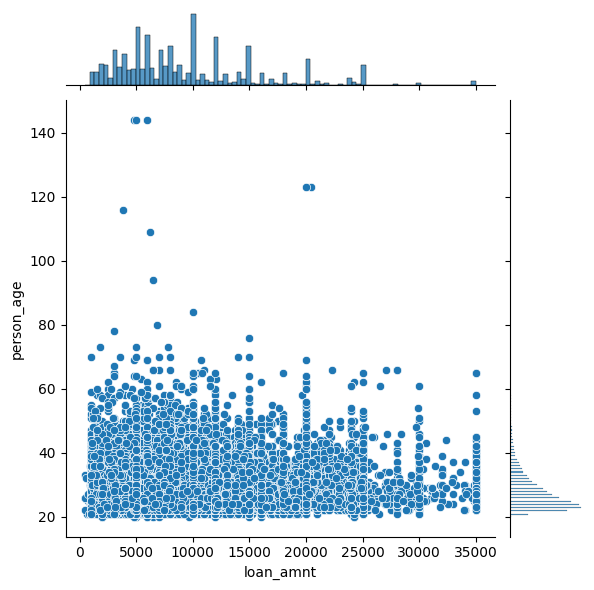

In [422]:
plt.figsize =(5,5)
sns.jointplot(x='loan_amnt', y='person_age', data=df)
plt.show()

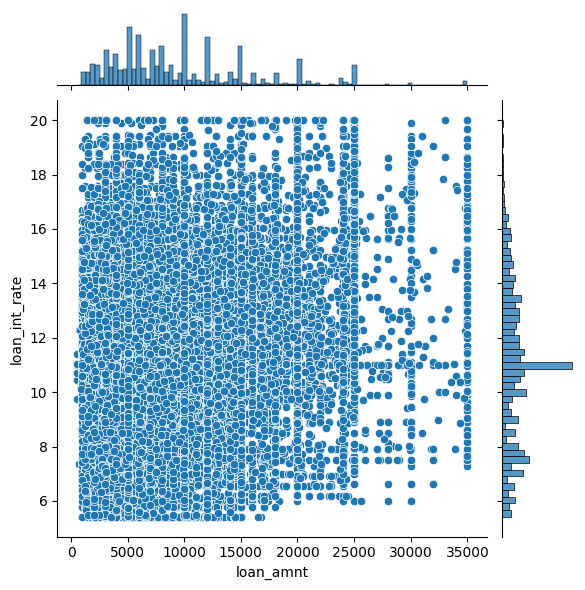

In [423]:

plt.figsize =(5,5)
sns.jointplot(x='loan_amnt', y='loan_int_rate', data=df)
plt.show()

In [424]:
#find the credit scoer > 600 for gender and Loan status 
df.query("`credit_score`>600").groupby('person_gender').sum()['loan_status']

person_gender
female    3352
male      4161
Name: loan_status, dtype: int64

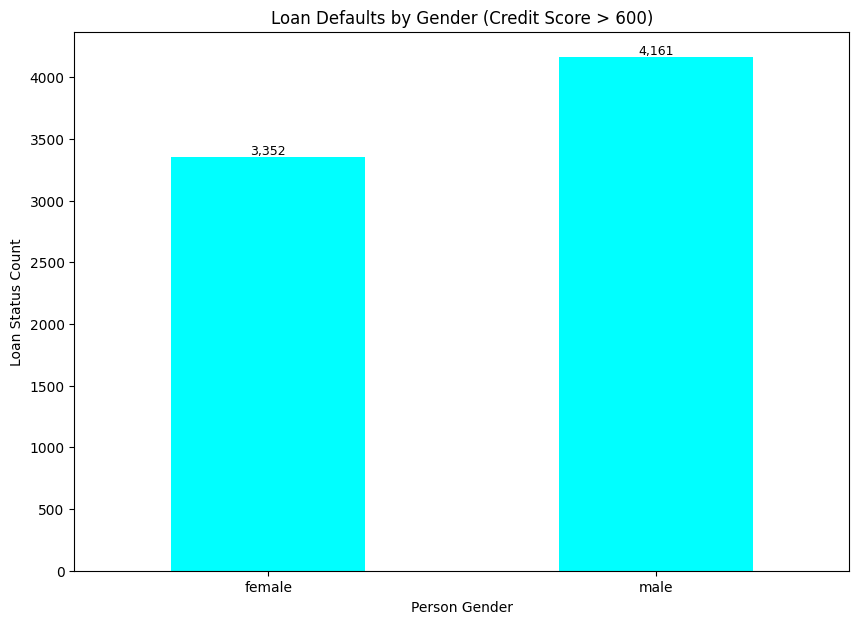

In [425]:
import matplotlib.pyplot as plt

df_plot = df.query("credit_score > 600").groupby('person_gender')['loan_status'].sum()

ax = df_plot.plot(kind='bar', figsize=(10, 7), color='cyan')

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.xlabel('Person Gender')
plt.ylabel('Loan Status Count')
plt.title('Loan Defaults by Gender (Credit Score > 600)')

plt.show()


In [426]:
df.groupby('previous_loan_defaults_on_file')['loan_intent'].count()

previous_loan_defaults_on_file
No     22142
Yes    22858
Name: loan_intent, dtype: int64

In [427]:
# check the count of default for yes and No 
def_loan_intent= df.groupby('loan_intent')\
.agg(defaults= ('previous_loan_defaults_on_file','count'))\
.sort_values(by='defaults',ascending=False)



def_loan_intent

,defaults
loan_intent,
EDUCATION,9153
MEDICAL,8548
VENTURE,7819
PERSONAL,7552
DEBTCONSOLIDATION,7145
HOMEIMPROVEMENT,4783


In [428]:
df[df['previous_loan_defaults_on_file']=='Yes'].\
groupby('loan_intent')['previous_loan_defaults_on_file']\
.count().sort_values(ascending=False)

loan_intent
EDUCATION            5000
VENTURE              4416
MEDICAL              4037
PERSONAL             3871
DEBTCONSOLIDATION    3255
HOMEIMPROVEMENT      2279
Name: previous_loan_defaults_on_file, dtype: int64

In [429]:
df[df['previous_loan_defaults_on_file']=='No']\
.groupby('loan_intent')['previous_loan_defaults_on_file']\
.count().sort_values(ascending=True)

loan_intent
HOMEIMPROVEMENT      2504
VENTURE              3403
PERSONAL             3681
DEBTCONSOLIDATION    3890
EDUCATION            4153
MEDICAL              4511
Name: previous_loan_defaults_on_file, dtype: int64

In [430]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

loan_status
0    35000
1    10000
Name: count, dtype: int64

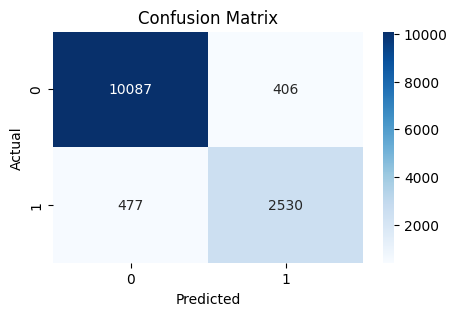

              precision    recall  f1-score   support

           0       0.95      0.96      0.96     10493
           1       0.86      0.84      0.85      3007

    accuracy                           0.93     13500
   macro avg       0.91      0.90      0.90     13500
weighted avg       0.93      0.93      0.93     13500

The recall_score is : 0.84
The roc_auc_score is : 0.98
['num__person_age' 'num__person_income' 'num__loan_amnt'
 'num__loan_int_rate' 'num__loan_percent_income'
 'cat__person_home_ownership' 'cat__loan_intent'
 'cat__previous_loan_defaults_on_file']
The mean of the score is 0.97
The std of the score is 0.01


['loan_model.pkl']

In [555]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler,RobustScaler,PowerTransformer,MinMaxScaler,OneHotEncoder
import category_encoders as ce
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.feature_selection import SelectFromModel, SelectKBest, RFE,f_classif,mutual_info_classif
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('loan_data.csv')

df_cat = df.select_dtypes(exclude = 'number')
df_num = df.select_dtypes(include = 'number').drop('loan_status',axis =1 )

df_cat.columns
df_cat_columns = ['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file']
df_num.columns
df_num_columns = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score']
df['loan_status'].value_counts()

X = df[df_num_columns + df_cat_columns]
y = df['loan_status']

X_train, X_test , y_train, y_test = train_test_split(X, y , test_size=0.30, random_state=42)



df_ref = SelectKBest(score_func=f_classif, k=8)
#df_ref = SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',bootstrap=True, random_state=42))
#df_ref = RFE(estimator=RandomForestClassifier(class_weight='balanced',bootstrap=True, random_state=42))

tranform_num_data = Pipeline(steps = [('nums',RobustScaler())])

tranform_cat_data = Pipeline(steps = [('cat',ce.OrdinalEncoder()),
                                      ('power',RobustScaler())
                                     ])

process = ColumnTransformer(transformers=[('num',tranform_num_data,df_num_columns ),
                                          ('cat', tranform_cat_data,df_cat_columns)
                                         ], remainder='drop')

model = Pipeline(steps =[('data',process),
                        ('SM', SMOTE(k_neighbors=5, random_state=42,sampling_strategy='auto')),
                        ('sel_feature',df_ref),
                        ('xgb', XGBClassifier( n_estimators=2000,
                                                 max_depth=5,
                                                 learning_rate=0.1,
                                                 subsample=0.8,
                                                 colsample_bytree=0.8,
                                                 random_state=42
))
                      #  ('rf', RandomForestClassifier(class_weight='balanced',bootstrap=True, random_state=42))                       
                        ])



model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_prob_log = model.predict_proba(X_test)[:,1]
thresold = 0.50
y_pred = (y_prob_log>=thresold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score

cm= confusion_matrix(y_test, y_pred)

plt.figure(figsize =(5,3))
sns.heatmap(cm, annot=True ,fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

cl= classification_report(y_test, y_pred)
print(cl)
print(f"The recall_score is : {recall_score(y_test,y_pred):0.2f}")
print(f"The roc_auc_score is : {roc_auc_score(y_test,y_prob_log):0.2f}")
feature_name = model.named_steps['data'].get_feature_names_out()

feature_selected = model.named_steps['sel_feature'].get_support()
print(feature_name[feature_selected])

scores = cross_val_score(model, X, y, cv=10, scoring='roc_auc')
print(f"The mean of the score is {scores.mean():0.2f}")
print(f"The std of the score is {scores.std():0.2f}")


import joblib

joblib.dump(model, 'loan_model.pkl')

['loan_model.pkl']

In [549]:
model_loaded = joblib.load('loan_model.pkl')

y_pred = model_loaded.predict(X_test)

In [550]:
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(13500,))

In [554]:
df[df['loan_status']==1]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
